# Data Visualization Ethics Challenge

In this activity, you’ll work with a simple dataset and examine two deliberately bad charts.  
Each one ignores multiple best practices for ethical and effective visualization.

Your job is to:

1. Review each chart and note at least three issues you see.  
2. Create a new chart (or charts) that present the data clearly, accurately, and honestly.  
3. Include clear labels, a cited data source, and a descriptive but neutral title.

**Remember:** Strong visualizations tell the truth, provide context, and avoid design choices that distort or mislead.


## Step 1: Load the dataset

We’re using a provided CSV file with fictional sales data for a coffee chain.  
No need to modify anything in this cell — just run it so the dataset loads into your notebook.  
Once loaded, take a quick look at the first few rows to get familiar with the columns and values.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

coffee_df = pd.read_csv("fake_coffee_chain_sales.csv")
coffee_df.head()

,Year,Month,Region,Category,Sales,Profit
0,2020,January,East,Espresso,14724,5290.46
1,2020,January,East,Lattes,11948,4138.77
2,2020,January,East,Tea,18660,5959.44
3,2020,January,East,Pastries,11265,2604.46
4,2020,January,East,Beans,8954,2613.22


## Step 2: Review the BAD Charts

Below are two deliberately poor visualizations.  
Your task: Carefully review each and take notes on what you think is wrong, misleading, or just poorly designed.  
Think about chart type, colors, scales, labeling, and whether the chart tells the truth.  


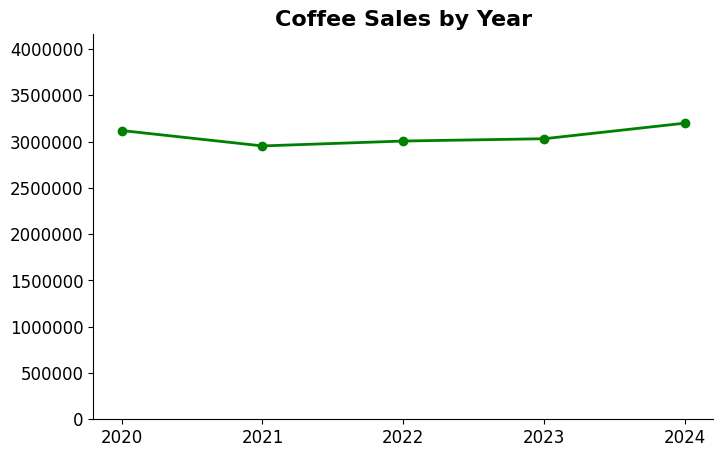

In [ ]:
plt.figure(figsize=(8,5))
subset = coffee_df.groupby("Year")["Sales"].sum().reset_index()

plt.plot(subset["Year"], subset["Sales"], color="green", linewidth=2, marker="o")
plt.ylim(0, subset["Sales"].max() * 1.3) 
plt.title("Coffee Sales by Year", fontsize=16, fontweight="bold", color="black")
plt.xticks(subset["Year"].astype(int), fontsize=12)
plt.yticks(fontsize=12)
plt.ticklabel_format(style='plain', axis='y')


ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.show()



### Write your notes about bad chart #1 here:
(double click to open this markdown cell and type into it)

1. The scale on the x and y axis were way off skewing the numbers. The x-axis was a decimal and i changed it to an integer. The y- axis was in scientific notation and I changed it to an integer
2. The line scaling was completely off skewing the line in the wrong direction (it actually trends upwards not down!) I updated that.
3. I removed the grid lines on the right and the left to make the chart more clear
4. I updated the line to be green instead of red to indicated good news
5. I updated the chart title to be black vs red to indicate strong profits. Red usually connotes something negative.

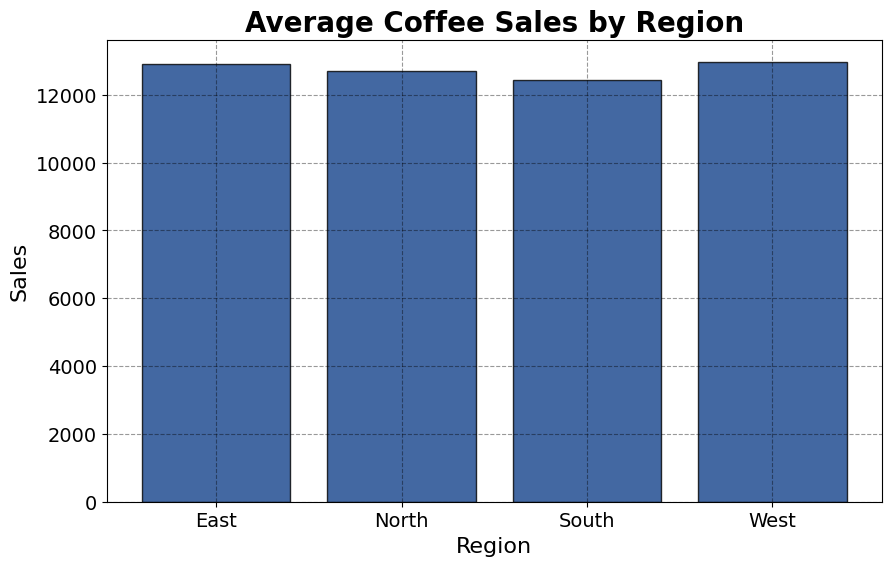

In [35]:
plt.figure(figsize=(10,6))
avg_sales = coffee_df.groupby("Region")["Sales"].mean().reset_index()

colors = ["#14428B"] * len(avg_sales)

plt.bar(avg_sales["Region"], avg_sales["Sales"], 
        color=colors, edgecolor="black", linewidth=1, alpha=0.8)
plt.title("Average Coffee Sales by Region", fontsize=20, fontweight="bold", color="black")
plt.grid(True, which='both', color='black', linestyle='--', alpha=.4)
plt.xlabel("Region", fontsize=16, color="black")
plt.ylabel("Sales", fontsize=16, color="black")
plt.xticks( fontsize=14, color="black")
plt.yticks(fontsize=14, color="black")
plt.tight_layout
plt.show()


### Write your notes about bad chart #2 here:
(double click to open this markdown cell and type into it)
1. The title of the chart had conflicting bright colors so I updated it to a more serious black. I also changed the title to something that made more sense to me.
2. The bar chart colors were jarring and confusing so I changed all the bars to be nice blue color.
3. The x-axis labels were orange and on an angle so I updated them to be black and horizontal.
4. The y-axis label was unprofessional and had odd colors so I updated it to be a professional black color with a title that was more serious.
5. The grid was too bold and covered up the data so I changed the transparency so that it faded behind the bar chart.

## Step 3: Your Turn – Make It Right

Now it’s your turn to fix things.  

- Start by thinking about a question you want to answer with this dataset.  
- Choose a visualization type that matches your question and the data structure.  
- Apply the best practices from our lessons: clear labeling, appropriate scale, purposeful color, simplicity, and accessibility.  
- Be honest - don’t manipulate the chart to make a point that the data doesn’t support.  

When you’re done, add your chart(s) below. You may create more than one if it helps tell the story better.  


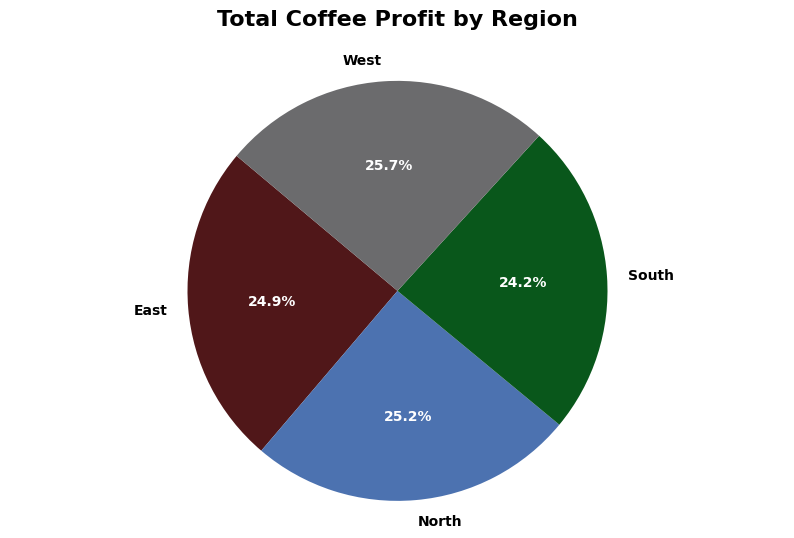

In [71]:
# Your GOOD visualization(s) here
region_profit = coffee_df.groupby("Region")["Profit"].sum()

# Pie chart
plt.figure(figsize=(10,6))

colors = { "North": "#4C72B0",  "South": "#09571B",  "East": "#501719", "West": "#6B6B6D"}
colors = [colors.get(region, "#DD8452") for region in region_profit.index]


wedges, texts, autotexts = plt.pie(
    region_profit,
    labels=region_profit.index,
    autopct="%1.1f%%",
    startangle=140,
    colors=colors,
     textprops={"fontweight": "bold"}
)

plt.setp(autotexts, color="white")

plt.title( "Total Coffee Profit by Region",  fontsize=16, fontweight="bold", pad=25)
plt.axis("equal") 
plt.show()